In [29]:
""" Run Instructions:
1. Run step by step
2. Modify variables throughtout depending on desired timeframe and data
3. Script works with "Fitted" and "Ne from Power" files. Does not work with "Resolved Velocity"
"""
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import madrigalWeb.madrigalWeb
import os
import h5py
import numpy as np
import pathlib

In [30]:
#CHANGE ME
user_fullname = "Benjamin Marcotte"
user_email = "bmarc@bu.edu"
user_affiliation = "ISR Summer School 2026"

maddat = madrigalWeb.madrigalWeb.MadrigalData('https://data.amisr.com/madrigal/')
#maddat = madrigalWeb.madrigalWeb.MadrigalData('https://cedar.openmadrigal.org/')

In [31]:
#instrument codes for AMISR
instcodes={'PFISR':61,
          'RISR-N':91,
          'RISR-C':92}

In [32]:
# Find an experiment that happened in the following time interval:
st=datetime.datetime(2026, 7, 20, 0,0)
et=datetime.datetime(2026, 7, 22, 23,59)

expList = maddat.getExperiments(instcodes['PFISR'],
                st.year, st.month, st.day, st.hour, st.minute, st.second,
                et.year, et.month, et.day, et.hour, et.minute, et.second)
for exp in expList:
    print(exp)

id: 30003610
realUrl: http://data.amisr.com/madrigal/madExperiment.cgi?exp=experiments0/2026/pfa/21jul26c&displayLevel=0&expTitle=MSWinds26H.v01+-+D-region+E-region+F-region+local+measurements
url: http://data.amisr.com/madrigal/madtoc/experiments0/2026/pfa/21jul26c
name: MSWinds26H.v01 - D-region E-region F-region local measurements
siteid: 3
sitename: SRI
instcode: 61
instname: Poker Flat IS Radar
startyear: 2026
startmonth: 7
startday: 21
starthour: 4
startmin: 0
startsec: 51
endyear: 2026
endmonth: 7
endday: 21
endhour: 6
endmin: 40
endsec: 56
isLocal: True
madrigalUrl: http://https://data.amisr.com/madrigal
PI: Asti Bhatt
PIEmail: asti.bhatt@sri.com
uttimestamp: 1784752455
access: 0
Madrigal version: 2.6

id: 30003611
realUrl: http://data.amisr.com/madrigal/madExperiment.cgi?exp=experiments0/2026/pfa/21jul26d&displayLevel=0&expTitle=ISRSchl2026Grp4Nightflare.v01+-+Analyze+impact+of+solar+flare+on+the+ionosphere+with+D-region+E-region+F-region+measurements
url: http://data.amisr.co

In [33]:
# Input Desired Experiment ID from list above into variable below:
selected_experiment_id = 30003611
fileList = maddat.getExperimentFiles(selected_experiment_id)
for file in fileList:
    print(os.path.basename(file.name),'\tkindat:',file.kindat,'desc:',file.kindatdesc)

pfa20260721.004_bc_nenotr_01min.001.h5 	kindat: 1000301 desc: Ne From Power - Barker/MPS Code (D-region) - 1 min
pfa20260721.004_bc_nenotr_03min.001.h5 	kindat: 1000303 desc: Ne From Power - Barker/MPS Code (D-region) - 3 min
pfa20260721.004_bc_nenotr_05min.001.h5 	kindat: 1000305 desc: Ne From Power - Barker/MPS Code (D-region) - 5 min
pfa20260721.004_bc_nenotr_10min.001.h5 	kindat: 1000310 desc: Ne From Power - Barker/MPS Code (D-region) - 10 min
pfa20260721.004_bc_nenotr_15min.001.h5 	kindat: 1000315 desc: Ne From Power - Barker/MPS Code (D-region) - 15 min
pfa20260721.004_bc_nenotr_20min.001.h5 	kindat: 1000320 desc: Ne From Power - Barker/MPS Code (D-region) - 20 min
pfa20260721.004_ac_nenotr_01min.001.h5 	kindat: 1000201 desc: Ne From Power - Alternating Code (E-region) - 1 min
pfa20260721.004_ac_fit_01min.001.h5 	kindat: 2000201 desc: Fitted - Alternating Code (E-region) - 1 min
pfa20260721.004_ac_nenotr_03min.001.h5 	kindat: 1000203 desc: Ne From Power - Alternating Code (E-reg

In [ ]:
# Input desired kindat value from list above into variable below:
# Works with "Fitted" and "Ne From Power" files. Does not work with "Resolved Velocity"
selected_file_kindat = 1000303
acfile=None
for file in fileList:
    if file.kindat == selected_file_kindat:
        acfile=file
        break
        
filename    = acfile.name
outfilename = os.path.basename(acfile.name)

file_path = pathlib.Path(outfilename)

if file_path.is_file():
    print(f"File {outfilename} already downloaded. Skipping download")
else:
    result = maddat.downloadFile(filename,outfilename, user_fullname, user_email, user_affiliation, 'hdf5')
    print(f"Done downloading {outfilename}")

File already downloaded. Skipping download
Done downloading pfa20260721.004_bc_nenotr_03min.001.h5


In [35]:
# Explore the HDF5 madrigal metadata
with h5py.File(outfilename,'r') as f:
    for key1,val1 in f.items():
        print(key1,val1)
        for key2,val2 in val1.items():
            print(" ",key2,val2)        

Data <HDF5 group "/Data" (2 members)>
  Array Layout <HDF5 group "/Data/Array Layout" (4 members)>
  Table Layout <HDF5 dataset "Table Layout": shape (22080,), type "|V200">
Metadata <HDF5 group "/Metadata" (6 members)>
  Data Parameters <HDF5 dataset "Data Parameters": shape (25,), type "|V98">
  Experiment Notes <HDF5 dataset "Experiment Notes": shape (78,), type "|V8">
  Experiment Parameters <HDF5 dataset "Experiment Parameters": shape (14,), type "|V16">
  Independent Spatial Parameters <HDF5 dataset "Independent Spatial Parameters": shape (1,), type "|V10">
  Parameters Used to Split Array Data <HDF5 dataset "Parameters Used to Split Array Data": shape (1,), type "|V21">
  _record_layout <HDF5 dataset "_record_layout": shape (1,), type "|V200">


In [36]:
# Explore the HDF5 madrigal data from the first beam in /Data/Array Layout
with h5py.File(outfilename,'r') as f:
    for key1,val1 in f["/Data/Array Layout"].items():
        print(key1,val1)
        for key2,val2 in val1.items():
            print(" ",key2,val2) 
            try:
                for key3,val3 in val2.items():
                    print("   ",key3,val3)      
            except:
                pass
        break

Array with beamid=64016  <HDF5 group "/Data/Array Layout/Array with beamid=64016 " (5 members)>
  1D Parameters <HDF5 group "/Data/Array Layout/Array with beamid=64016 /1D Parameters" (11 members)>
    Data Parameters <HDF5 dataset "Data Parameters": shape (10,), type "|V88">
    azm <HDF5 dataset "azm": shape (40,), type "<f8">
    beamid <HDF5 dataset "beamid": shape (40,), type "<i8">
    cbadl <HDF5 dataset "cbadl": shape (40,), type "<f8">
    elm <HDF5 dataset "elm": shape (40,), type "<f8">
    numrxaeu <HDF5 dataset "numrxaeu": shape (40,), type "<f8">
    numtxaeu <HDF5 dataset "numtxaeu": shape (40,), type "<f8">
    pl <HDF5 dataset "pl": shape (40,), type "<f8">
    power <HDF5 dataset "power": shape (40,), type "<f8">
    rfreq <HDF5 dataset "rfreq": shape (40,), type "<f8">
    tfreq <HDF5 dataset "tfreq": shape (40,), type "<f8">
  2D Parameters <HDF5 group "/Data/Array Layout/Array with beamid=64016 /2D Parameters" (4 members)>
    Data Parameters <HDF5 dataset "Data Pa

In [37]:
if "nenotr" in outfilename:
    with h5py.File(outfilename,'r') as f:
        PFISR_data = []
        for dat in f['Data/Array Layout'].values():
            outdct={}
            outdct['bid'] = dat['1D Parameters/beamid'][0]
            outdct['azm'] = dat['1D Parameters/azm'][0]
            outdct['elm'] = dat['1D Parameters/elm'][0]
            outdct['ne'] = 10**(dat['2D Parameters/popl'][:])
            outdct['dne'] = 10**(dat['2D Parameters/dpopl'][:])
            
            outdct['range'] = dat['range'][:]
            outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
            tstmp = dat['timestamps'][:]
            outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]
            PFISR_data.append(outdct) 
elif "fit" in outfilename:
    with h5py.File(outfilename,'r') as f:
        PFISR_data = []
        for dat in f['Data/Array Layout'].values():
            outdct={}
            outdct['bid'] = dat['1D Parameters/beamid'][0]
            outdct['azm'] = dat['1D Parameters/azm'][0]
            outdct['elm'] = dat['1D Parameters/elm'][0]
            outdct['ne'] = dat['2D Parameters/ne'][:]     # different from old SRI madrigal 2
            outdct['dne'] = dat['2D Parameters/dne'][:]   # different from old SRI madrigal 2
            outdct['te'] = dat['2D Parameters/te'][:]
            outdct['dte'] = dat['2D Parameters/dte'][:]
            outdct['ti'] = dat['2D Parameters/ti'][:]
            outdct['dti'] = dat['2D Parameters/dti'][:]
            outdct['vo'] = dat['2D Parameters/vo'][:]
            outdct['dvo'] = dat['2D Parameters/dvo'][:]
            
            outdct['range'] = dat['range'][:]
            outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
            tstmp = dat['timestamps'][:]
            outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]
            PFISR_data.append(outdct)
else:
    print("Cannot currently handle this file type.")

In [38]:
for i,d in enumerate(PFISR_data):
    print(d['bid'],d['azm'],d['elm'])

64016 14.039999961853027 90.0
64157 -154.3000030517578 77.5
64964 -34.689998626708984 66.08999633789062
65066 75.02999877929688 65.55999755859375


In [39]:
# Input index of desired beam (starting at 0) from list above into variable below
selected_beam_id = 0
beam_data = PFISR_data[selected_beam_id]

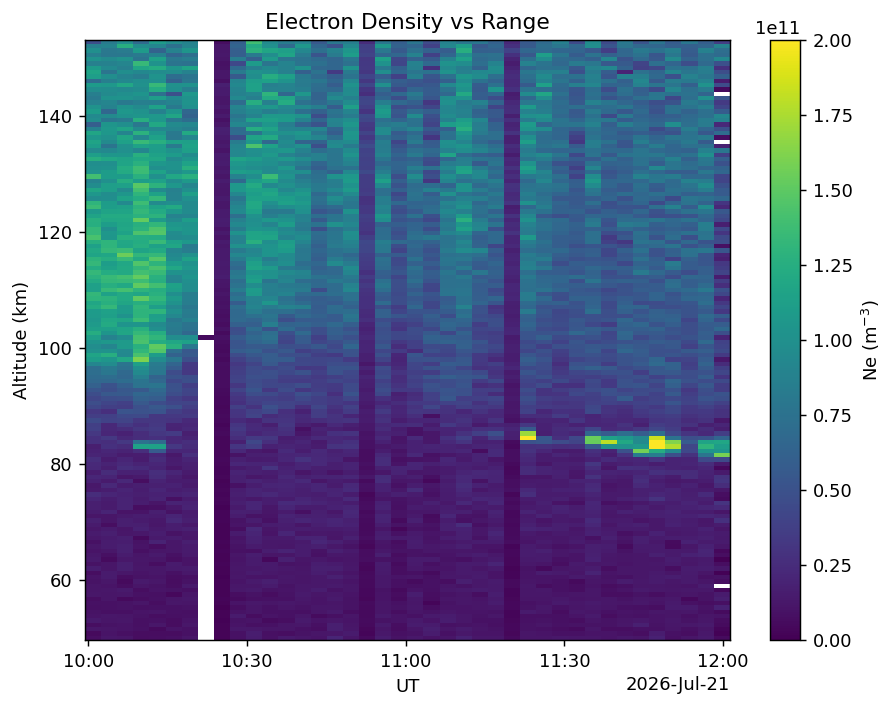

In [40]:
fig,ax=plt.subplots(figsize=(8,6), dpi=130)
clrs = ax.pcolormesh(mdates.date2num(beam_data['time']),
                     beam_data['altitude'],
                     beam_data['ne'],
                     vmin=0,vmax=2e11,shading='nearest')

locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title('Electron Density vs Range') # Use metadata to make more descriptive

cb=fig.colorbar(clrs)
cb.set_label('Ne (m$^{-3}$)')

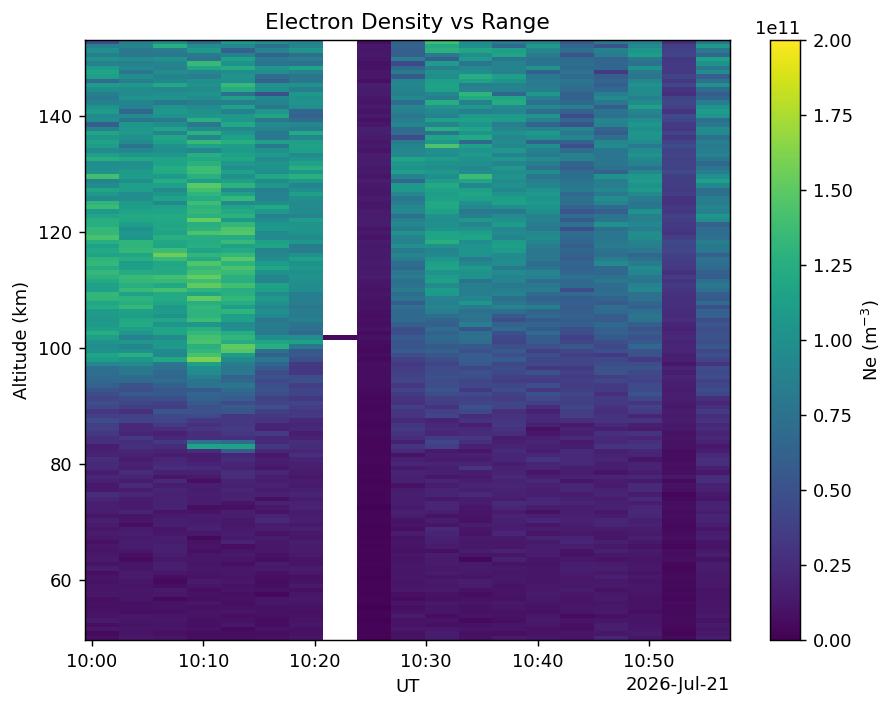

In [41]:
# Enter cutoff times below
start_time_year = 2026
start_time_month = 7
start_time_day = 21
start_time_hour = 10
start_time_minute = 0

end_time_year = 2026
end_time_month = 7
end_time_day = 21
end_time_hour = 11
end_time_minute = 0

start_time = datetime.datetime(
    start_time_year, start_time_month, start_time_day, start_time_hour, start_time_minute, 0,
    tzinfo=datetime.timezone.utc
)

# Find the datetime with the smallest absolute time difference (now including month/day)
start_time_index = min(
    range(len(beam_data['time'])),
    key=lambda i: abs((beam_data['time'][i] - start_time).total_seconds())
)

end_time = datetime.datetime(
    end_time_year, end_time_month, end_time_day, end_time_hour, end_time_minute, 0,
    tzinfo=datetime.timezone.utc
)

end_time_index = min(
    range(len(beam_data['time'])),
    key=lambda i: abs((beam_data['time'][i] - end_time).total_seconds())
)

fig,ax=plt.subplots(figsize=(8,6), dpi=130)
clrs = ax.pcolormesh(mdates.date2num(beam_data['time'][start_time_index:end_time_index]),
                     beam_data['altitude'],
                     beam_data['ne'][:, start_time_index:end_time_index],
                     vmin=0,vmax=2e11,shading='nearest')

locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title('Electron Density vs Range') # Use metadata to make more descriptive

cb=fig.colorbar(clrs)
cb.set_label('Ne (m$^{-3}$)')